<a href="https://colab.research.google.com/github/TienManh15072007/AI_HOMEWORK1/blob/main/HOMEWORKAILESSION1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#BÀI 23.1
import folium
from folium.plugins import MarkerCluster
UEH = [10.7756, 106.6920]
m = folium.Map(location=UEH, zoom_start=15)
folium.Marker(
    location=UEH,
    popup="UEH - Đại học Kinh tế TP.HCM",
    tooltip="UEH",
    icon=folium.Icon(color="red", icon="info-sign")
).add_to(m)
# Tạo các layer
hospital_layer = folium.FeatureGroup(name="Bệnh viện")
mall_layer = folium.FeatureGroup(name="Trung tâm thương mại")
gov_layer = folium.FeatureGroup(name="Hành chính")
park_layer = folium.FeatureGroup(name="Công viên")
transport_layer = folium.FeatureGroup(name="Giao thông")
#TẠO 5 ĐỊA ĐIỂM
folium.Marker([10.7738,106.6908],popup="Bệnh viện Bình Dân",tooltip="Hospital",icon=folium.Icon(color="blue")).add_to(hospital_layer)
folium.Marker([10.7805,106.6992],popup="Diamond Plaza",tooltip="Mall",icon=folium.Icon(color="green")).add_to(mall_layer)
folium.Marker([10.7823,106.6879],popup="UBND Quận 3",tooltip="Government",icon=folium.Icon(color="purple")).add_to(gov_layer)
folium.Marker([10.7777,106.6915],popup="Công viên Tao Đàn",tooltip="Park",icon=folium.Icon(color="lightgreen")).add_to(park_layer)
folium.Marker([10.7720,106.6980],popup="Trạm xe buýt Bến Thành",tooltip="Transport",icon=folium.Icon(color="orange")).add_to(transport_layer)
hospital_layer.add_to(m)
mall_layer.add_to(m)
gov_layer.add_to(m)
park_layer.add_to(m)
transport_layer.add_to(m)
folium.LayerControl().add_to(m)
m


In [ ]:
#BÀI 23.2
import folium,time
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

geolocator = Nominatim(user_agent="ueh_ai_project", timeout=10)
center_location = geolocator.geocode("UEH University Ho Chi Minh City")
center = (center_location.latitude, center_location.longitude)
# 10 địa điểm
places = [
    "Ben Thanh Market Ho Chi Minh City",
    "Tao Dan Park Ho Chi Minh City",
    "Diamond Plaza Ho Chi Minh City",
    "Independence Palace Ho Chi Minh City",
    "War Remnants Museum Ho Chi Minh City",
    "Saigon Centre Ho Chi Minh City",
    "Notre Dame Cathedral Ho Chi Minh City",
    "Nguyen Hue Walking Street Ho Chi Minh City",
    "Tan Dinh Market Ho Chi Minh City",
    "Bui Vien Walking Street Ho Chi Minh City"
]
m = folium.Map(location=center, zoom_start=13)
folium.Marker(center,popup="UEH",icon=folium.Icon(color="red")).add_to(m)
# xử lý từng địa điểm
for place in places:
    try:
        loc = geolocator.geocode(place)
        time.sleep(1)
        point = (loc.latitude, loc.longitude)
        dist = geodesic(center, point).km
# marker
        folium.Marker(point,popup=f"Cách kho: {dist:.1f} km",tooltip=place,icon=folium.Icon(color="blue")).add_to(m)
 # line nối UEH
        folium.PolyLine( [center, point], color="green",weight=2).add_to(m)

    except:
        print("Lỗi:", place)

m


In [ ]:
#BÀI 23.3
import folium, random
from folium.plugins import HeatMap
center = [10.7756, 106.6920]
m = folium.Map(location=center,zoom_start=20)
# Giả lập 80 đơn hàng quanh UEH
orders = []
for order in range(50):
      latitude_order = 10.7756 + random.uniform(-0.005,-0.005)
      longtitude_order = 106.6920 + random.uniform(-0.005,0.005)
      orders.append([latitude_order,longtitude_order])
for order in range(20):
      latitude_order = 10.7756 + random.uniform(-0.003,0.003)
      longtitude_order = 106.6920 + random.uniform(-0.003,0.003)
      orders.append([latitude_order,longtitude_order])
for order in range(10):
      latitude_order = 10.7756 + random.uniform(-0.007,0.007)
      longtitude_order = 106.6920 + random.uniform(-0.007,0.007)
      orders.append([latitude_order,longtitude_order])
HeatMap(orders,radius=19,blue=16).add_to(m)
folium.Marker(center,popup="UEH",icon=folium.Icon(color="red")).add_to(m)
m
#Vùng nóng quanh UEH cho thấy nhu cầu tiêu dùng cao của sinh viên. Doanh nghiệp có thể bố trí shipper, kho mini, quán ăn hoặc quảng cáo tại đây để tăng hiệu quả kinh doanh.






In [ ]:
#Bài 23.4
import folium
import pandas as pd
center = [10.7769, 106.7009]
m = folium.Map(location=center, zoom_start=11)
districts = [
    {"name":"Quận 1", "location":[10.7756,106.7009], "orders":950},
    {"name":"Quận 3", "location":[10.7829,106.6874], "orders":870},
    {"name":"Quận 5", "location":[10.7540,106.6677], "orders":620},
    {"name":"Bình Thạnh", "location":[10.8106,106.7091], "orders":710},
    {"name":"Phú Nhuận", "location":[10.7991,106.6800], "orders":540}
]
for d in districts:
    if d["orders"] >= 900: color = "red"
    elif d["orders"] >= 700: color = "orange"
    else: color = "green"
    folium.Circle(point=d["location"],radius=d["orders"] * 3,color=color,fill=True,fill_opacity=0.45,popup=f'{d["name"]}<br>Orders: {d["orders"]}').add_to(m)
m
# Quận 1 và Quận 3 có nhu cầu cao nên nên tăng shipper, kho mini hoặc quảng cáo. Các quận nhu cầu thấp có thể gom đơn để tiết kiệm chi phí vận hành.



In [ ]:
#Bài 23.5
import folium
from geopy.distance import geodesic
warehouse = (10.7756, 106.6920)
#khách hàng
customers = [
  ("Khách 1", (10.7810,106.6950)),
    ("Khách 2", (10.7900,106.7100)),
    ("Khách 3", (10.7600,106.6800)),
    ("Khách 4", (10.7520,106.6600)),
    ("Khách 5", (10.7700,106.7000))
]
m = folium.Map(location=warehouse,zoom_start = 15)
folium.Marker(warehouse,popup="kho hàng",icon=folium.Icon(color="blue")).add_to(m)
folium.Circle(warehouse,radius=4000,color="green",fill=True,fill_opacity=0.35,popup="Bán kính phục vụ 3km").add_to(m)
for name,location in customers:
       distance = geodesic(warehouse,location).km
       if distance <= 3: color ="green";status = "Trong vùng phục vụ"
       else: color = "red" ; status = "Ngoài vùng phục vụ"
       folium.Marker(location,popup=f"{name}<br>{distance: .1f}km<br>{status}",icon=folium.Icon(color=color)).add_to(m)
m


In [2]:
pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.2 MB/s eta 0:00:00


Khu vuc: District 1, Ho Chi Minh City, Vietnam
So nut giao: 989
So doan duong: 2090
Chieu dai duong trung binh (m): 79.03
Mat do mang (doan/km2): 260.31


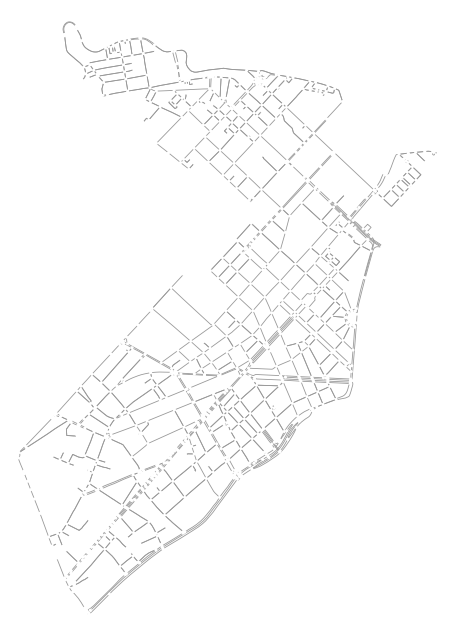

In [3]:
#BÀI 23.6
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
place="District 1, Ho Chi Minh City, Vietnam"
G=ox.graph_from_place(place,network_type="drive")
nodes=len(G.nodes)
edges=len(G.edges)
lengths=[data["length"] for u,v,k,data in G.edges(keys=True,data=True)]
avg_length=sum(lengths)/len(lengths)
area=ox.geocode_to_gdf(place).to_crs(epsg=3857).area.iloc[0]/1000000
density=edges/area
print("Khu vuc:",place)
print("So nut giao:",nodes)
print("So doan duong:",edges)
print("Chieu dai duong trung binh (m):",round(avg_length,2))
print("Mat do mang (doan/km2):",round(density,2))
fig,ax=ox.plot_graph(G,node_size=5,edge_linewidth=0.6,bgcolor="white",show=False,close=False)
plt.show()


In [4]:
#BÀI 23.7
import osmnx as ox
import networkx as nx
import folium
place="District 1, Ho Chi Minh City, Vietnam"
G=ox.graph_from_place(place,network_type="drive")
start_point=(10.7769,106.7009)
end_point=(10.7725,106.6980)
start_node=ox.distance.nearest_nodes(G,start_point[1],start_point[0])
end_node=ox.distance.nearest_nodes(G,end_point[1],end_point[0])
route_dijkstra=nx.shortest_path(G,start_node,end_node,weight="length",method="dijkstra")
route_astar=nx.astar_path(G,start_node,end_node,heuristic=lambda a,b:((G.nodes[a]["y"]-G.nodes[b]["y"])**2+(G.nodes[a]["x"]-G.nodes[b]["x"])**2)**0.5,weight="length")
dist_dijkstra=nx.path_weight(G,route_dijkstra,weight="length")
dist_astar=nx.path_weight(G,route_astar,weight="length")
print("Dijkstra distance (m):",round(dist_dijkstra,2))
print("A Star distance (m):",round(dist_astar,2))
print("Dijkstra nodes:",len(route_dijkstra))
print("A Star nodes:",len(route_astar))
m=folium.Map(location=start_point,zoom_start=15)
folium.Marker(location=start_point,popup="Start",icon=folium.Icon(color="green")).add_to(m)
folium.Marker(location=end_point,popup="End",icon=folium.Icon(color="red")).add_to(m)
coords_dijkstra=[(G.nodes[n]["y"],G.nodes[n]["x"]) for n in route_dijkstra]
coords_astar=[(G.nodes[n]["y"],G.nodes[n]["x"]) for n in route_astar]
folium.PolyLine(coords_dijkstra,color="blue",weight=5,popup="Dijkstra").add_to(m)
folium.PolyLine(coords_astar,color="orange",weight=3,popup="A Star").add_to(m)
m

Dijkstra distance (m): 796.4
A Star distance (m): 796.4
Dijkstra nodes: 9
A Star nodes: 9


In [5]:
#BÀI 23.8
import folium
import random
from geopy.distance import geodesic
center=(10.7756,106.6920)
cars=[(10.7756+random.uniform(-0.02,0.02),106.6920+random.uniform(-0.02,0.02)) for i in range(5)]
customers=[(10.7756+random.uniform(-0.02,0.02),106.6920+random.uniform(-0.02,0.02)) for i in range(5)]
used=[]
m=folium.Map(location=center,zoom_start=14)
for i,c in enumerate(cars):
    folium.Marker(location=c,popup="Car "+str(i+1),icon=folium.Icon(color="blue")).add_to(m)
for i,u in enumerate(customers):
    best=min([(j,geodesic(u,cars[j]).km) for j in range(5) if j not in used],key=lambda x:x[1])
    used.append(best[0])
    folium.Marker(location=u,popup="Customer "+str(i+1),icon=folium.Icon(color="red")).add_to(m)
    folium.PolyLine([cars[best[0]],u],color="green",weight=3,popup="Car "+str(best[0]+1)).add_to(m)
m


In [6]:
#BÀI 23.9
import folium
import random
import pandas as pd
from sklearn.cluster import KMeans
center=(10.7756,106.6920)
points=[(10.7756+random.uniform(-0.03,0.03),106.6920+random.uniform(-0.03,0.03)) for i in range(30)]
df=pd.DataFrame(points,columns=["lat","lon"])
model=KMeans(n_clusters=3,random_state=42)
df["cluster"]=model.fit_predict(df[["lat","lon"]])
centers=model.cluster_centers_
colors=["red","blue","green"]
m=folium.Map(location=center,zoom_start=13)
for i in range(len(df)):
    c=df.loc[i,"cluster"]
    folium.CircleMarker(location=(df.loc[i,"lat"],df.loc[i,"lon"]),radius=5,color=colors[c],fill=True,fill_opacity=0.8,popup="Cluster "+str(c+1)).add_to(m)
for i in range(3):
    folium.Marker(location=(centers[i][0],centers[i][1]),popup="Hub "+str(i+1),icon=folium.Icon(color="black")).add_to(m)
m

In [7]:
#BÀI 23.10
import folium
import random
import pandas as pd
center=(10.7756,106.6920)
data=[]
for i in range(35):
    lat=10.7756+random.uniform(-0.03,0.03)
    lon=106.6920+random.uniform(-0.03,0.03)
    speed=random.randint(10,60)
    volume=random.randint(80,300)
    risk=(60-speed)*0.7+volume*0.1
    data.append([lat,lon,speed,volume,risk])
df=pd.DataFrame(data,columns=["lat","lon","speed","volume","risk"])
m=folium.Map(location=center,zoom_start=13)
for i in range(len(df)):
    r=df.loc[i,"risk"]
    if r>=35: color="red"
    elif r>=20: color="orange"
    else: color="green"
    folium.CircleMarker(location=(df.loc[i,"lat"],df.loc[i,"lon"]),radius=7,color=color,fill=True,fill_opacity=0.8,popup="Risk "+str(round(r,1))).add_to(m)
old_route=[(10.7600,106.6800),(10.7700,106.6880),(10.7800,106.6960),(10.7900,106.7050)]
new_route=[(10.7600,106.6800),(10.7680,106.6840),(10.7760,106.6900),(10.7850,106.7000)]
folium.PolyLine(old_route,color="red",weight=5,popup="Congested Route").add_to(m)
folium.PolyLine(new_route,color="blue",weight=5,popup="Alternative Route").add_to(m)
m


In [16]:
#BÀI 23.11
import folium
import random
import pandas as pd
from sklearn.linear_model import LinearRegression
center=(10.7756,106.6920)
data=[]
for i in range(80):
    zone=random.randint(1,4)
    hour=random.randint(0,23)
    lat=10.7756+random.uniform(-0.03,0.03)
    lon=106.6920+random.uniform(-0.03,0.03)
    demand=15+zone*12+hour*1.5+random.randint(-5,5)
    data.append([zone,hour,lat,lon,demand])
df=pd.DataFrame(data,columns=["zone","hour","lat","lon","demand"])
X=df[["zone","hour"]]
y=df["demand"]
model=LinearRegression()
model.fit(X,y)
future=[]
for z in range(1,5):
    pred=model.predict([[z,18]])[0]
    lat=10.7756+random.uniform(-0.025,0.025)
    lon=106.6920+random.uniform(-0.025,0.025)
    future.append([z,lat,lon,pred])
m=folium.Map(location=center,zoom_start=13)
for row in future:
    if row[3]>=65:  color="red"
    elif row[3]>=50:  color="orange"
    else:  color="green"
    folium.CircleMarker(location=(row[1],row[2]),radius=8,color=color,fill=True,fill_opacity=0.8,popup="Zone "+str(row[0])+" Demand "+str(round(row[3],1))).add_to(m)
print("Du bao nhu cau luc 18h")
for row in future:
    print("Zone",row[0],":",round(row[3],1))
m




Du bao nhu cau luc 18h
Zone 1 : 53.6
Zone 2 : 65.8
Zone 3 : 77.9
Zone 4 : 90.1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [10]:
#BÀI 23.12
import folium
import random
from geopy.distance import geodesic

center=(10.7756,106.6920)

warehouses={
    "Kho A":(10.7756,106.6920),
    "Kho B":(10.7900,106.7100)
}

customers=[(10.7756+random.uniform(-0.03,0.03),106.6920+random.uniform(-0.03,0.03)) for i in range(10)]

routes={"Kho A":[],"Kho B":[]}

for customer in customers:
    best=min(warehouses,key=lambda w:geodesic(customer,warehouses[w]).km)
    routes[best].append(customer)

def route_distance(start,points):
    total=0
    current=start
    remain=points[:]
    while remain:
        nxt=min(remain,key=lambda p:geodesic(current,p).km)
        total+=geodesic(current,nxt).km
        current=nxt
        remain.remove(nxt)
    total+=geodesic(current,start).km
    return total

normal=0
best=0

for name in warehouses:
    start=warehouses[name]
    pts=routes[name]
    if len(pts)>0:
        normal+=sum(geodesic(start,p).km for p in pts)*2
        best+=route_distance(start,pts)

print("Tong km khong toi uu:",round(normal,2))
print("Tong km toi uu:",round(best,2))
print("Tiet kiem:",round(normal-best,2))

m=folium.Map(location=center,zoom_start=13)

for name,loc in warehouses.items():
    folium.Marker(location=loc,popup=name,icon=folium.Icon(color="red")).add_to(m)

colors=["blue","green"]

for i,name in enumerate(routes):
    start=warehouses[name]
    remain=routes[name][:]
    current=start
    path=[start]
    while remain:
        nxt=min(remain,key=lambda p:geodesic(current,p).km)
        path.append(nxt)
        current=nxt
        remain.remove(nxt)
    path.append(start)
    for p in routes[name]:
        folium.CircleMarker(location=p,radius=5,color=colors[i],fill=True,fill_opacity=0.8).add_to(m)
    folium.PolyLine(path,color=colors[i],weight=4,popup=name).add_to(m)

m


Tong km khong toi uu: 46.16
Tong km toi uu: 26.29
Tiet kiem: 19.86


In [12]:
#BÀI 23.13
import folium, random

center=(10.7756,106.6920)
m=folium.Map(location=center,zoom_start=13)
m=folium.Map(location=center,zoom_start=13)
points=folium.FeatureGroup(name="Diem giao dich")
zones=folium.FeatureGroup(name="Vung kinh doanh")
routes=folium.FeatureGroup(name="Tuyen duong")

for i in range(8):
    lat=10.7756+random.uniform(-0.025,0.025)
    lon=106.6920+random.uniform(-0.025,0.025)
    folium.Marker(location=(lat,lon),popup="Chi nhanh "+str(i+1),icon=folium.Icon(color="blue")).add_to(points)

folium.Circle(location=(10.7850,106.7050),radius=2500,color="red",fill=True,fill_opacity=0.25,popup="Vung nhu cau cao").add_to(zones)
folium.Circle(location=(10.7650,106.6820),radius=2200,color="green",fill=True,fill_opacity=0.25,popup="Vung tiem nang").add_to(zones)

folium.PolyLine([(10.7600,106.6800),(10.7700,106.6880),(10.7820,106.7000)],color="purple",weight=5,popup="Tuyen chinh").add_to(routes)
folium.PolyLine([(10.7700,106.6750),(10.7780,106.6900),(10.7900,106.7100)],color="orange",weight=5,popup="Tuyen du phong").add_to(routes)

points.add_to(m)
zones.add_to(m)
routes.add_to(m)

folium.LayerControl().add_to(m)

m


In [14]:
#BÀI 23.14
import folium
import random
import time
center=(10.7756,106.6920)
cars=[
{"name":"Xe 1","pos":[10.7700,106.6850],"target":[10.7900,106.7100],"status":"Dang giao"},
{"name":"Xe 2","pos":[10.7850,106.7000],"target":[10.7600,106.6750],"status":"Dang giao"},
{"name":"Xe 3","pos":[10.7650,106.7050],"target":[10.7800,106.6880],"status":"Dang giao"}
]

for step in range(1,11):
    m=folium.Map(location=center,zoom_start=13)
    for car in cars:
        lat=car["pos"][0]
        lon=car["pos"][1]
        tlat=car["target"][0]
        tlon=car["target"][1]
        car["pos"][0]=lat+(tlat-lat)*0.2
        car["pos"][1]=lon+(tlon-lon)*0.2
        if abs(car["pos"][0]-tlat)<0.001 and abs(car["pos"][1]-tlon)<0.001:
            car["status"]="Da giao"
        folium.Marker(location=car["pos"],popup=car["name"]+" - "+car["status"],icon=folium.Icon(color="blue")).add_to(m)
        folium.PolyLine([car["pos"],car["target"]],color="green",weight=3).add_to(m)
    print("Buoc",step)
    display(m)
    time.sleep(1)


Buoc 1


Buoc 2


Buoc 3


Buoc 4


Buoc 5


Buoc 6


Buoc 7


Buoc 8


Buoc 9


Buoc 10


In [ ]:
#BÀI 23.15
#ĐỀ XUẤT ỨNG DỤNG: HỆ THỐNG TỐI ƯU HÓA LỘ TRÌNH THU GOM RÁC THÔNG MINH (SMART WASTE LOGISTICS)
#1. Bài toán
#Trong quản lý đô thị hiện đại, việc thu gom rác theo lộ trình cố định gây lãng phí nhiên liệu và nhân công (xe vẫn chạy qua các thùng rác còn trống). Bài toán đặt ra là: Dựa trên dữ liệu mức độ đầy của các thùng rác, hãy xác định những thùng cần thu gom và tìm lộ trình ngắn nhất để tối ưu hóa chi phí vận hành.

#2. Dữ liệu (Giả lập)
#Vị trí: Tọa độ (Lat, Lon) của 20 thùng rác trong một khu vực đô thị.

#Trạng thái: Mức độ đầy (%) được cập nhật từ cảm biến IoT giả lập.

#Điểm xuất phát (Depot): Tọa độ của bãi xe tập kết rác.

#3. Phương pháp AI & Thuật toán
#Phân nhóm (Clustering - K-Means): Sử dụng K-Means để chia các thùng rác cần thu gom thành các khu vực dựa trên vị trí địa lý, giúp phân bổ cho nhiều xe tải khác nhau.

#Tối ưu hóa lộ trình (Heuristic - Nearest Neighbor): Giải quyết bài toán người giao hàng (TSP) để tìm thứ tự di chuyển qua các điểm sao cho tổng quãng đường là ngắn nhất.

#4. Cách trực quan hóa bản đồ
#Sử dụng thư viện Folium.

#Marker: Màu đỏ cho thùng rác đầy (>70%), màu xanh cho thùng rác chưa cần thu gom.

#Polyline: Vẽ đường kẻ nối các điểm theo lộ trình đã được tối ưu.

#5. Giá trị ứng dụng thực tiễn
#Tiết kiệm chi phí: Giảm quãng đường di chuyển không cần thiết, từ đó giảm chi phí xăng dầu và bảo dưỡng xe.

#Bảo vệ môi trường: Giảm lượng khí thải CO2 từ xe rác.

#Nâng cao hiệu quả: Đảm bảo các thùng rác đầy luôn được xử lý kịp thời, tránh ô nhiễm môi trường đô thị.